# Renewables vs CO₂ Emissions: Visualization Improvement
##  Applied Visualization Principles
- **Decluttering:** Reduced visual noise by simplifying the layout and removing unnecessary visual elements  
- **Overplotting reduction:** Replaced scatter plot with a hexbin density plot to better represent large volumes of overlapping data  
- **Clarity:** Improved axis labels and added a more descriptive, insight-driven title  
- **Visual hierarchy:** Used a contrasting trendline to clearly highlight the relationship between variables  
- **Color encoding:** Applied a color gradient to represent the distribution of countries across renewable energy and CO₂ emission levels  
- **Insight focus:** Made the negative relationship between renewable energy share and CO₂ emissions more visible and interpretable  

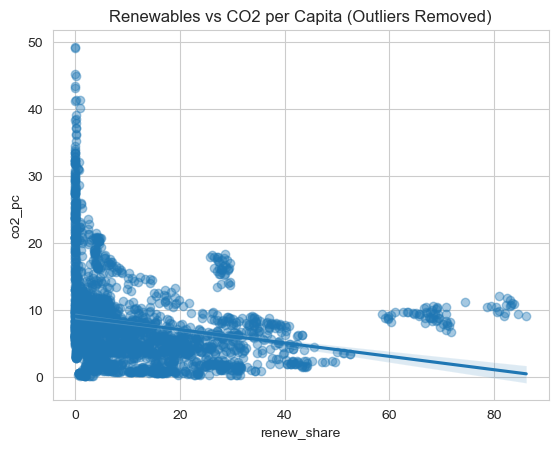

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
renew = pd.read_csv(r"C:\Users\caste\Downloads\renewable-share-energy\renewable-share-energy.csv")
co2 = pd.read_csv(r"C:\Users\caste\Downloads\co2-emissions-per-capita\co2-emissions-per-capita.csv")
renew = renew.rename(columns={
    "Share of primary energy consumption from renewables (%)": "renew_share"
})

co2 = co2.rename(columns={
    "CO2 emissions per capita": "co2_pc"
})
renew = renew[renew["Year"] >= 1990]
co2 = co2[co2["Year"] >= 1990]
df = pd.merge(renew, co2, on=["Entity", "Year"], how="inner")
df = df.dropna()
df = df.rename(columns={
    "Renewables": "renew_share",
    "CO₂ emissions per capita": "co2_pc"
})
yearly = df.groupby("Year").mean(numeric_only=True)
df_clean = df[df["co2_pc"] < 50]
sns.regplot(data=df_clean,
            x="renew_share",
            y="co2_pc",
            scatter_kws={"alpha":0.4})

plt.title("Renewables vs CO2 per Capita (Outliers Removed)")
plt.show()

C:\Users\caste\AppData\Local\Temp\ipykernel_30628\3849749533.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\caste\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


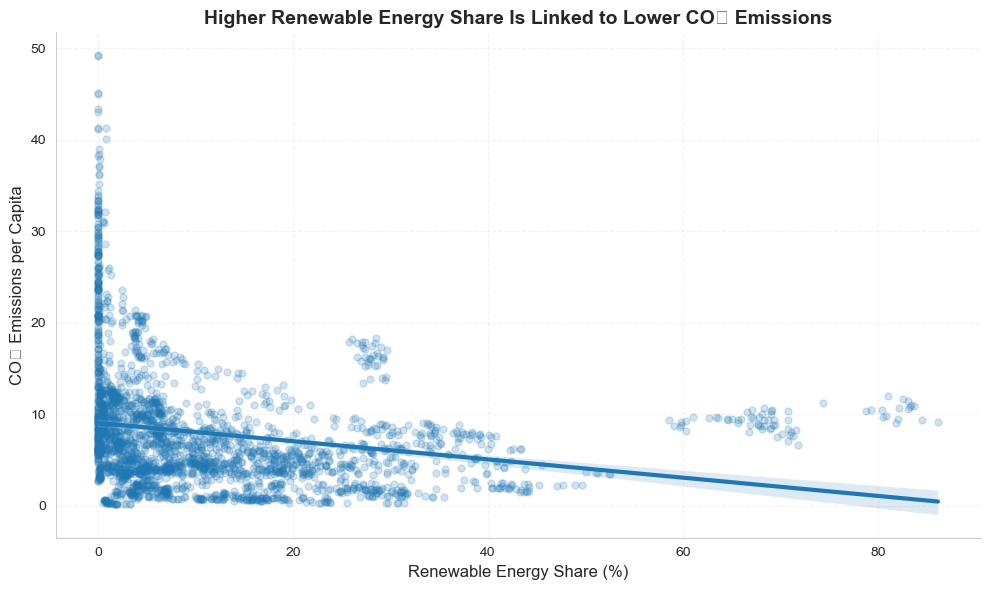

In [22]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x="renew_share",
    y="co2_pc",
    scatter_kws={
        "alpha": 0.2,
        "s": 25
    },
    line_kws={
        "linewidth": 3
    }
)

plt.title("Higher Renewable Energy Share Is Linked to Lower CO₂ Emissions", fontsize=14, weight="bold")
plt.xlabel("Renewable Energy Share (%)", fontsize=12)
plt.ylabel("CO₂ Emissions per Capita", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

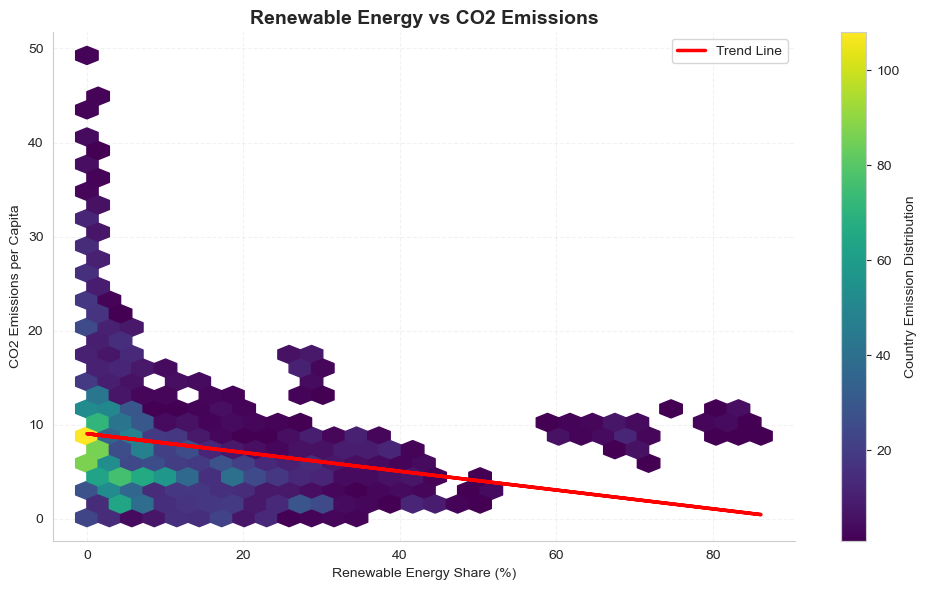

In [27]:
import numpy as np

plt.figure(figsize=(10, 6))

hb = plt.hexbin(
    df_clean["renew_share"],
    df_clean["co2_pc"],
    gridsize=30,
    cmap="viridis",   
    mincnt=1
)

cb = plt.colorbar(hb)
cb.set_label("Country Emission Distribution")
z = np.polyfit(df_clean["renew_share"], df_clean["co2_pc"], 1)
p = np.poly1d(z)

plt.plot(
    df_clean["renew_share"],
    p(df_clean["renew_share"]),
    color="red",
    linewidth=2.5,
    label="Trend Line"
)

plt.title("Renewable Energy vs CO2 Emissions", fontsize=14, weight="bold")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("CO2 Emissions per Capita")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Creating dataset and Static Visualizations with Matplotlib

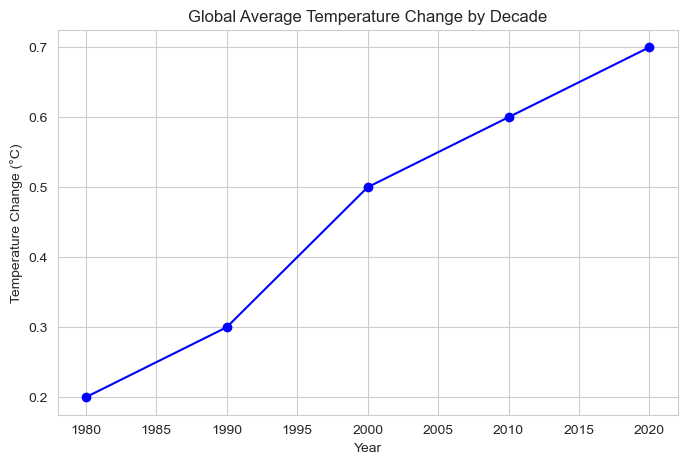

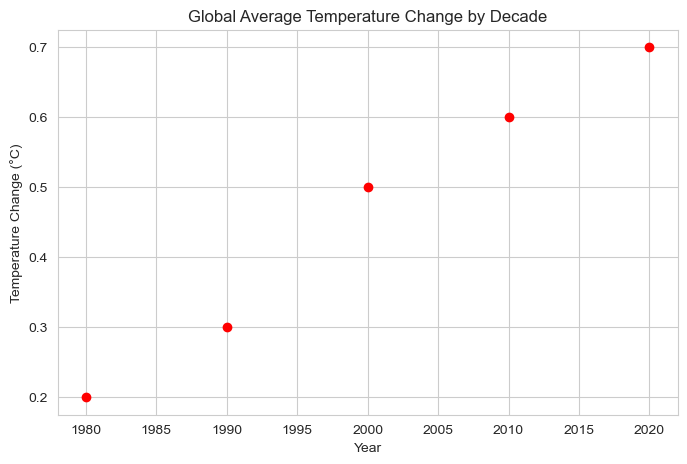

In [28]:
import matplotlib.pyplot as plt

# Data
years = [1980, 1990, 2000, 2010, 2020]
temp_change = [0.2, 0.3, 0.5, 0.6, 0.7]  # Average global temperature change in degrees Celsius

# Creating a line graph
plt.figure(figsize=(8, 5))
plt.plot(years, temp_change, marker='o', linestyle='-', color='b')
plt.title('Global Average Temperature Change by Decade')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')
plt.grid(True)
plt.show()

# Creating a scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(years, temp_change, color='r')
plt.title('Global Average Temperature Change by Decade')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')
plt.grid(True)
plt.show()

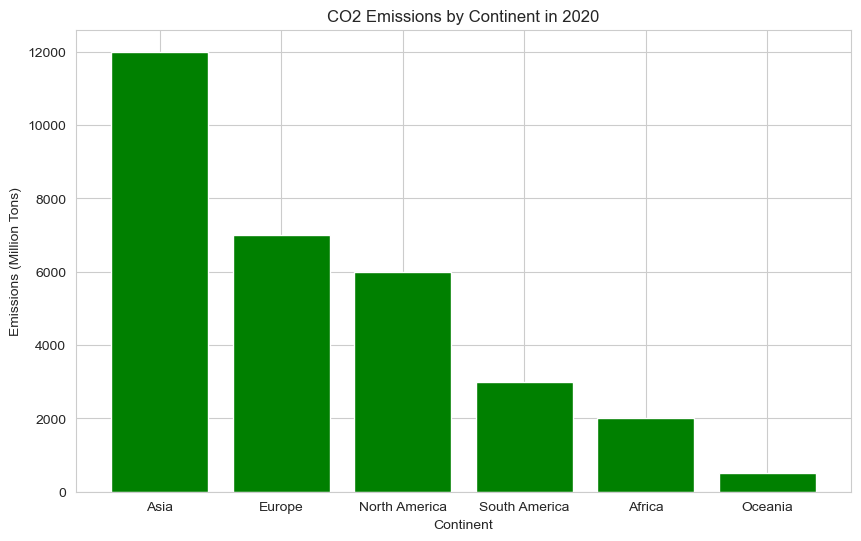

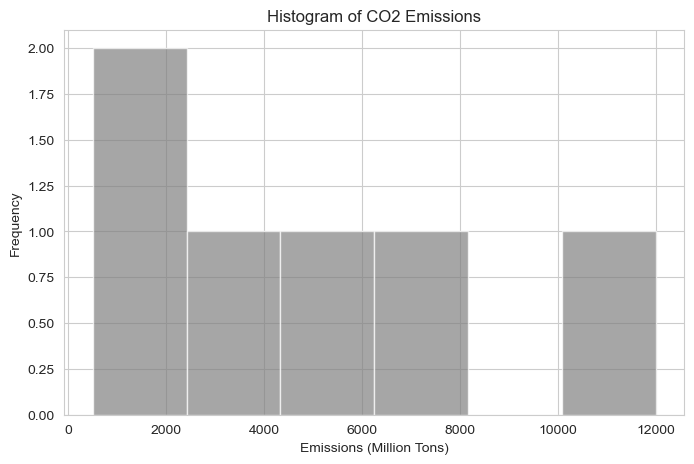

In [29]:
# Data
continents = ['Asia', 'Europe', 'North America', 'South America', 'Africa', 'Oceania']
emissions = [12000, 7000, 6000, 3000, 2000, 500]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(continents, emissions, color='green')
plt.title('CO2 Emissions by Continent in 2020')
plt.xlabel('Continent')
plt.ylabel('Emissions (Million Tons)')
plt.show()

# Histogram of the emissions, to see the distribution
plt.figure(figsize=(8, 5))
plt.hist(emissions, bins=6, color='gray', alpha=0.7)
plt.title('Histogram of CO2 Emissions')
plt.xlabel('Emissions (Million Tons)')
plt.ylabel('Frequency')
plt.show()

# Generate a line graph and a bar chart detailing CO2 emissions over the years, applying best practices in design and layout.
Color encoding reinforces temporal progression and highlights increasing temperature intensity over time

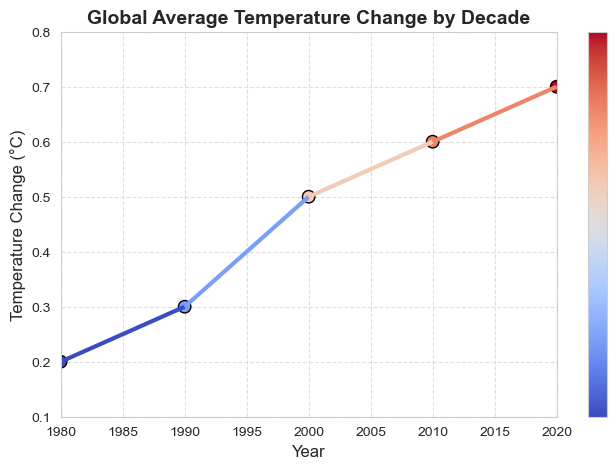

In [37]:
import numpy as np
from matplotlib.collections import LineCollection
points = np.array([years, temp_change]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(min(temp_change), max(temp_change))

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(np.array(temp_change))
lc.set_linewidth(3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.add_collection(lc)
ax.scatter(years, temp_change, c=temp_change, cmap='coolwarm', s=80, edgecolor='black')
ax.set_title('Global Average Temperature Change by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Change (°C)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(min(years), max(years))
ax.set_ylim(min(temp_change) - 0.1, max(temp_change) + 0.1)

cbar = plt.colorbar(lc)
cbar.set_ticks([])
plt.show()

# Advanced Static Visualizations with Seaborn

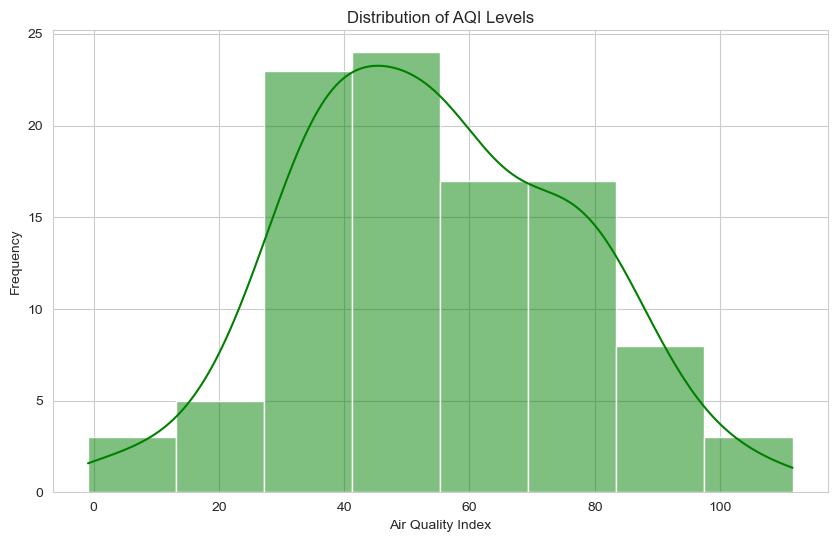

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Data
countries = ['USA', 'Canada', 'Germany', 'France', 'India', 'China', 'Brazil', 'Australia']
aqi = np.random.normal(loc=50, scale=20, size=100)  # Simulated AQI data

# Creating a histogram with Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(aqi, kde=True, color='green')
plt.title('Distribution of AQI Levels')
plt.xlabel('Air Quality Index')
plt.ylabel('Frequency')
plt.show()

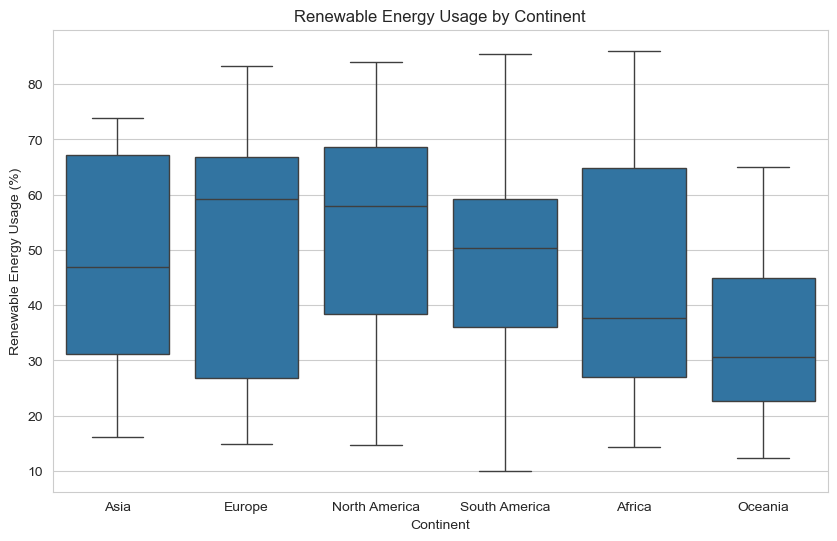

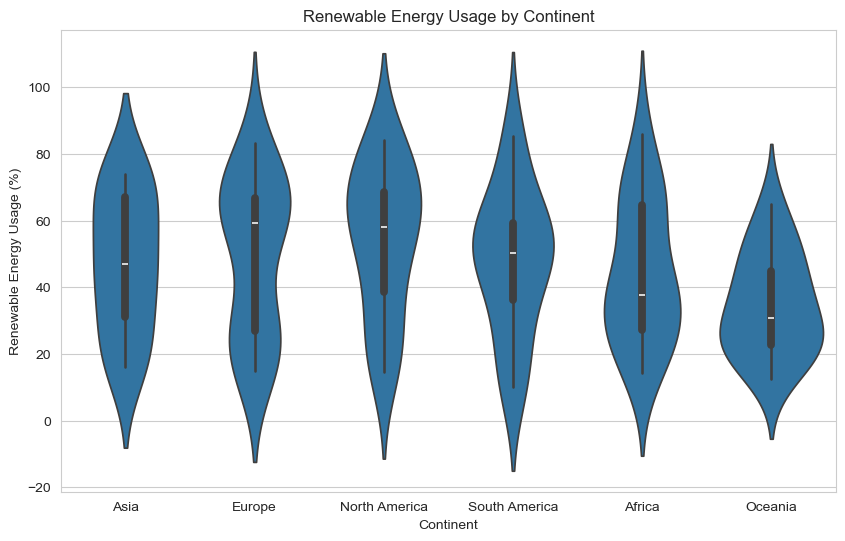

In [39]:
# Data
continents = ['Asia', 'Europe', 'North America', 'South America', 'Africa', 'Oceania'] * 15
renewable_energy = np.random.uniform(low=10, high=90, size=90)  # Simulated data

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=continents, y=renewable_energy)
plt.title('Renewable Energy Usage by Continent')
plt.xlabel('Continent')
plt.ylabel('Renewable Energy Usage (%)')
plt.show()

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=continents, y=renewable_energy)
plt.title('Renewable Energy Usage by Continent')
plt.xlabel('Continent')
plt.ylabel('Renewable Energy Usage (%)')
plt.show()

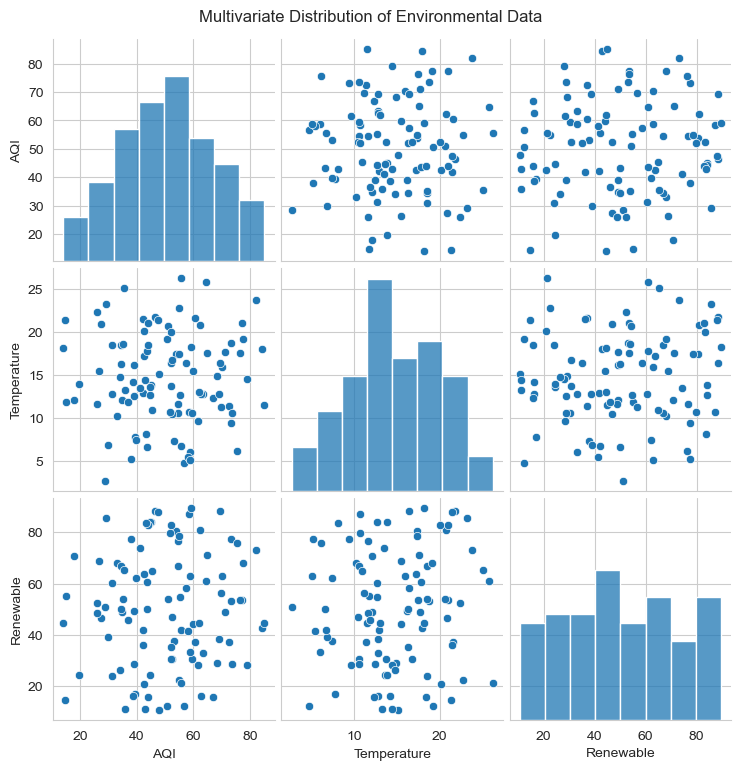

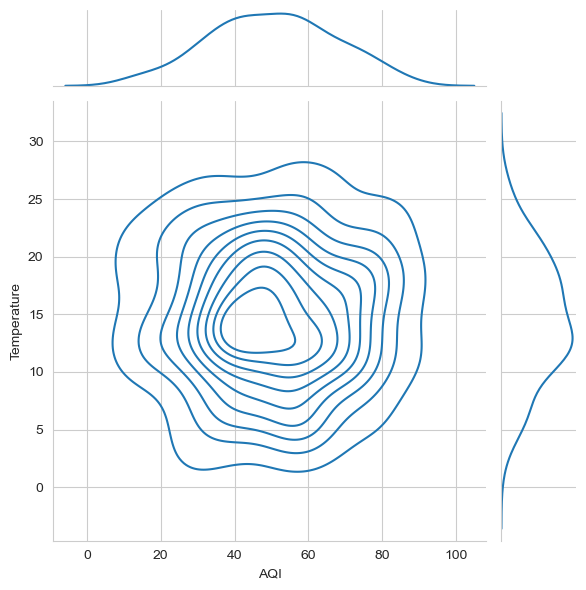

In [40]:
import pandas as pd

# Data
data = {
    'AQI': np.random.normal(loc=50, scale=15, size=100),
    'Temperature': np.random.normal(loc=15, scale=5, size=100),
    'Renewable': np.random.uniform(low=10, high=90, size=100)
}
df = pd.DataFrame(data)

# Pair plot
sns.pairplot(df)
plt.suptitle('Multivariate Distribution of Environmental Data', y=1.02)
plt.show()

# Joint plot for AQI and Temperature
sns.jointplot(x='AQI', y='Temperature', data=df, kind='kde')
plt.show()

C:\Users\caste\AppData\Local\Temp\ipykernel_30628\280983933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=continents, y=renewable_energy, palette='cool')


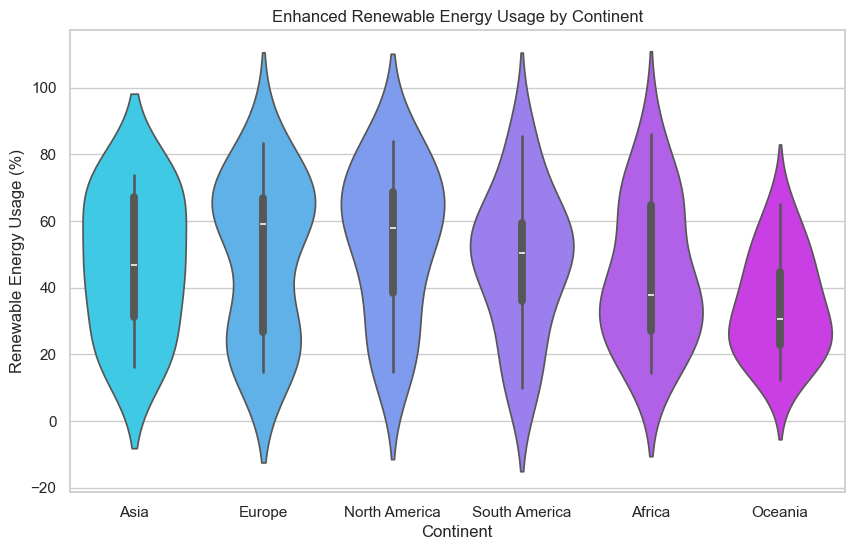

In [41]:
# Setting a theme
sns.set_theme(style='whitegrid')

# Enhanced violin plot with customizations
plt.figure(figsize=(10, 6))
sns.violinplot(x=continents, y=renewable_energy, palette='cool')
plt.title('Enhanced Renewable Energy Usage by Continent')
plt.xlabel('Continent')
plt.ylabel('Renewable Energy Usage (%)')
plt.show()

# Advanced Static Visualizations with Seaborn
## Air Quality Index (AQI) Analysis Using Box Plots and Violin Plots

This notebook explores Air Quality Index (AQI) data across different countries using Seaborn static visualizations.  
The aim is to demonstrate how box plots and violin plots help communicate statistical concepts such as distribution, spread, median, variability, and potential outliers.

These visualizations are useful because they allow quick comparison between groups while also revealing deeper patterns in the data.

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Reproducibility
np.random.seed(42)
countries = ['Netherlands', 'Germany', 'India', 'China', 'Brazil', 'Australia']

aqi_data = {
    'Netherlands': np.random.normal(loc=42, scale=8, size=40),
    'Germany': np.random.normal(loc=50, scale=10, size=40),
    'India': np.random.normal(loc=95, scale=20, size=40),
    'China': np.random.normal(loc=85, scale=18, size=40),
    'Brazil': np.random.normal(loc=60, scale=12, size=40),
    'Australia': np.random.normal(loc=35, scale=7, size=40)
}

data = []
for country, values in aqi_data.items():
    for value in values:
        data.append([country, max(0, value)])  # prevent negative AQI
df = pd.DataFrame(data, columns=['Country', 'AQI'])
df.head()

,Country,AQI
0,Netherlands,45.973713
1,Netherlands,40.893886
2,Netherlands,47.181508
3,Netherlands,54.184239
4,Netherlands,40.126773


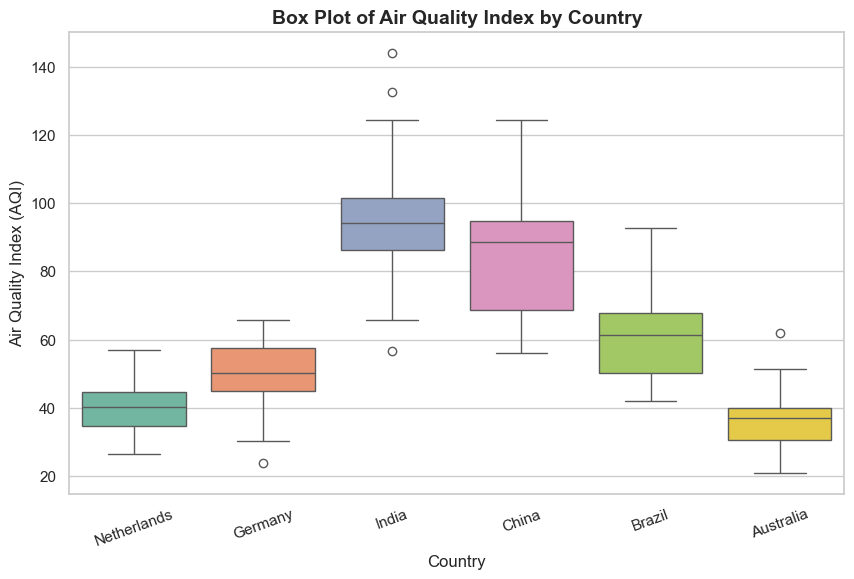

In [43]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Country', y='AQI', hue='Country', palette='Set2', legend=False)
plt.title('Box Plot of Air Quality Index by Country', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)
plt.xticks(rotation=20)
plt.show()

## Why a Box Plot is Suitable

The box plot is appropriate for AQI data because it summarizes key statistical measures for each country:

- **Median**: shows the central AQI value
- **Interquartile Range (IQR)**: shows where the middle 50% of values lie
- **Whiskers**: show the spread of the data
- **Outliers**: highlight unusually high or low AQI values

This makes the box plot effective for comparing air quality levels between countries in a compact and statistically meaningful way.

## Insights from the Box Plot

From the box plot, it is possible to compare the typical AQI level in each country.  
Countries with higher medians indicate generally poorer air quality.  
Countries with wider boxes or longer whiskers show more variability in AQI values.  
Outliers may represent unusually polluted days or rare environmental conditions.

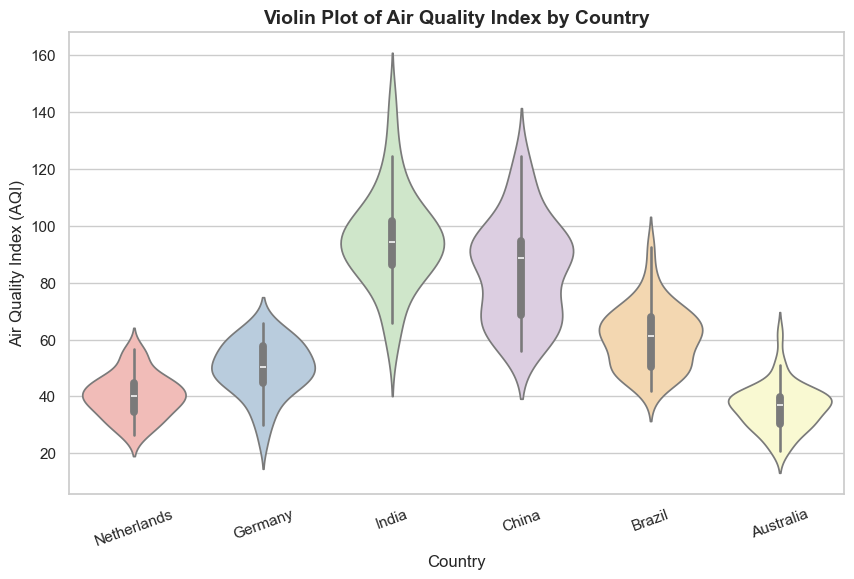

In [44]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Country', y='AQI', hue='Country', palette='Pastel1', legend=False)

plt.title('Violin Plot of Air Quality Index by Country', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)
plt.xticks(rotation=20)
plt.show()

## Why a Violin Plot is Suitable

The violin plot is useful because it shows not only summary statistics, but also the **shape of the distribution**.  
This helps reveal whether AQI values are:

- concentrated around certain levels,
- widely spread,
- skewed,
- or distributed in multiple peaks.

Compared with the box plot, the violin plot provides a richer view of how the AQI values are distributed within each country.

## Insights from the Violin Plot

The violin plot makes it easier to see density patterns.  
A wider section of the violin indicates that more AQI values are concentrated in that range.  
Narrow sections indicate fewer observations.

This allows deeper interpretation of the air quality data, such as whether a country has mostly stable AQI levels or a more irregular distribution.

# Interactive Visualizations with Plotly

In [53]:
pip install plotly

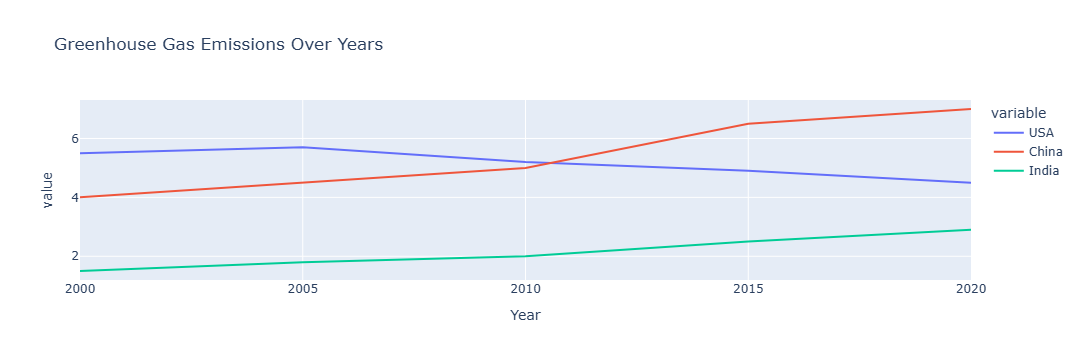

In [54]:
import plotly.express as px
import pandas as pd

# Data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'USA': [5.5, 5.7, 5.2, 4.9, 4.5],
    'China': [4.0, 4.5, 5.0, 6.5, 7.0],
    'India': [1.5, 1.8, 2.0, 2.5, 2.9]
}
df = pd.DataFrame(data)

# Line graph
fig = px.line(df, x='Year', y=['USA', 'China', 'India'], title='Greenhouse Gas Emissions Over Years')
fig.show()

In [46]:
# " line graph showing energy consumption between 200 and 2020, distinguishing between renewable and non-renewable sources thanks to a drop-down menu."

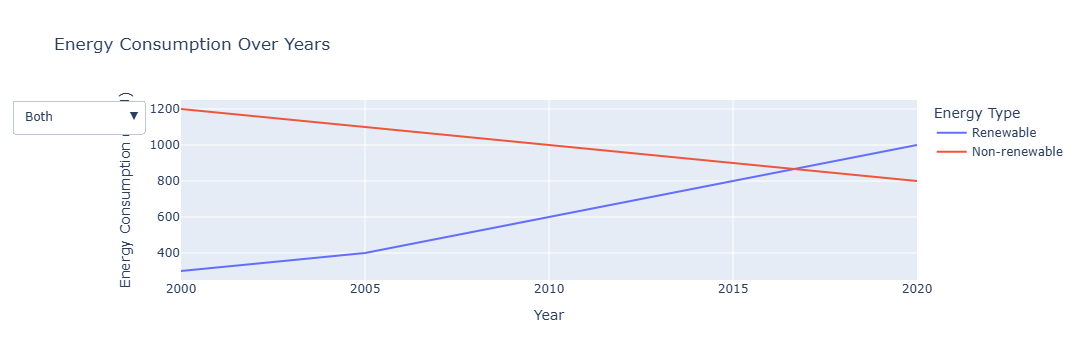

In [47]:
# Data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'Renewable': [300, 400, 600, 800, 1000],
    'Non-renewable': [1200, 1100, 1000, 900, 800]
}
df = pd.DataFrame(data)

# Interactive plot with dropdown
fig = px.line(df, x='Year', y=['Renewable', 'Non-renewable'],
              title='Energy Consumption Over Years',
              labels={'value': 'Energy Consumption (in PJ)', 'variable': 'Energy Type'})
fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            buttons=list([
                dict(label="Both",
                     method="update",
                     args=[{"y": [df['Renewable'], df['Non-renewable']]}]),
                dict(label="Renewable",
                     method="update",
                     args=[{"y": [df['Renewable'], None]}]),
                dict(label="Non-renewable",
                     method="update",
                     args=[{"y": [None, df['Non-renewable']]}]),
            ]),
        )
    ]
)
fig.show()

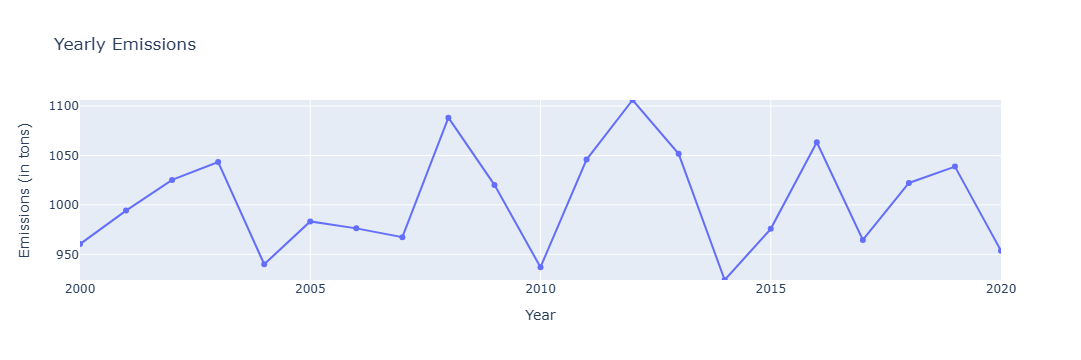

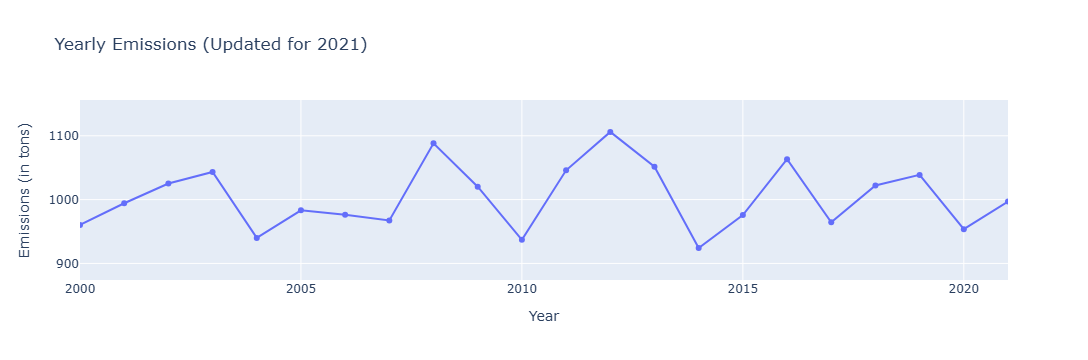

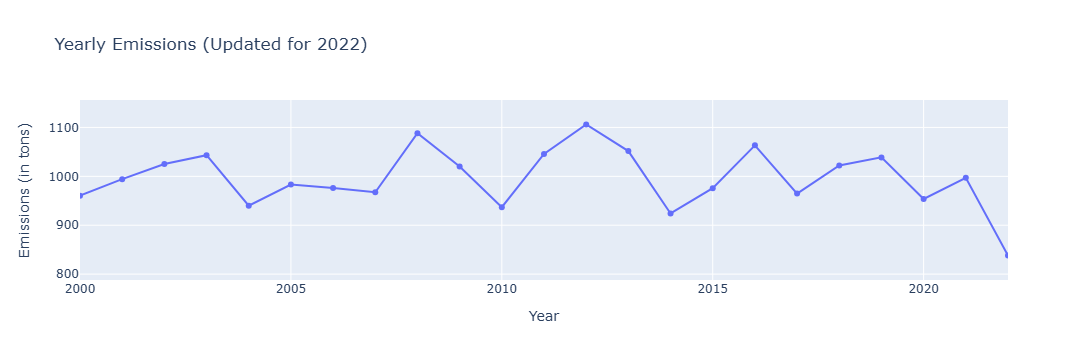

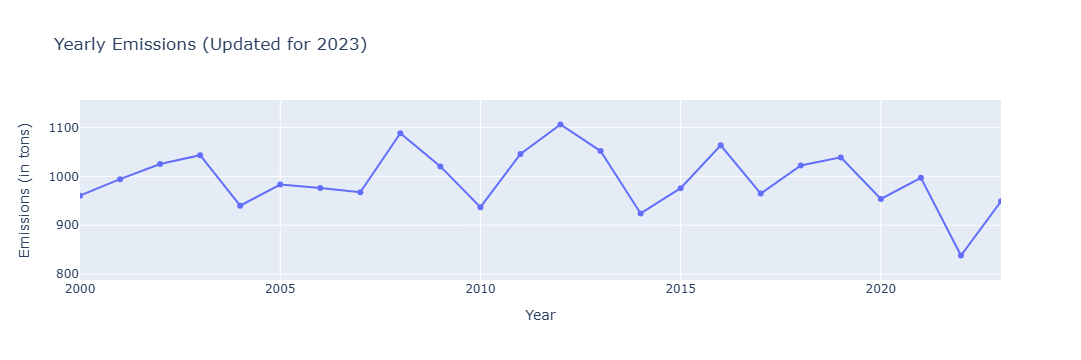

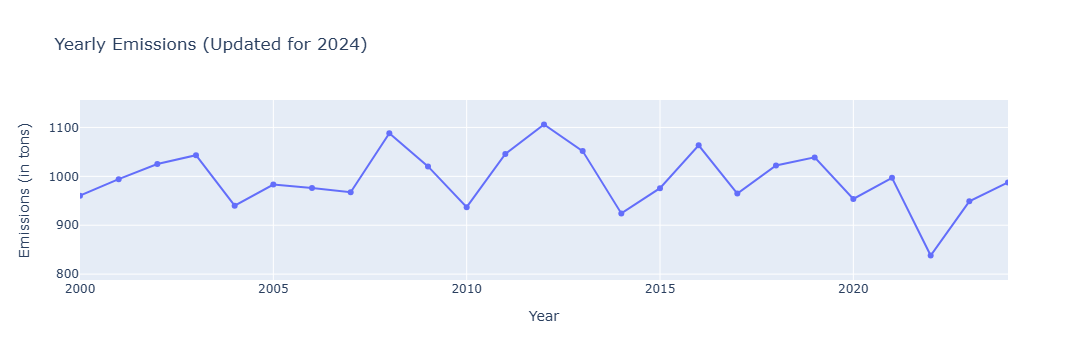

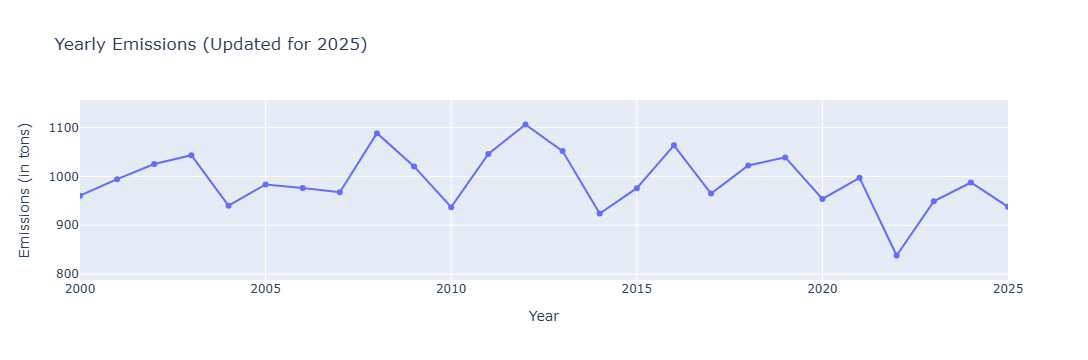

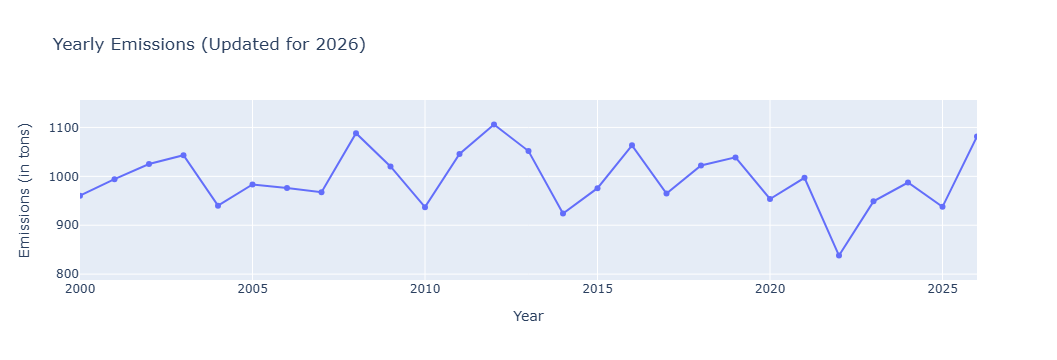

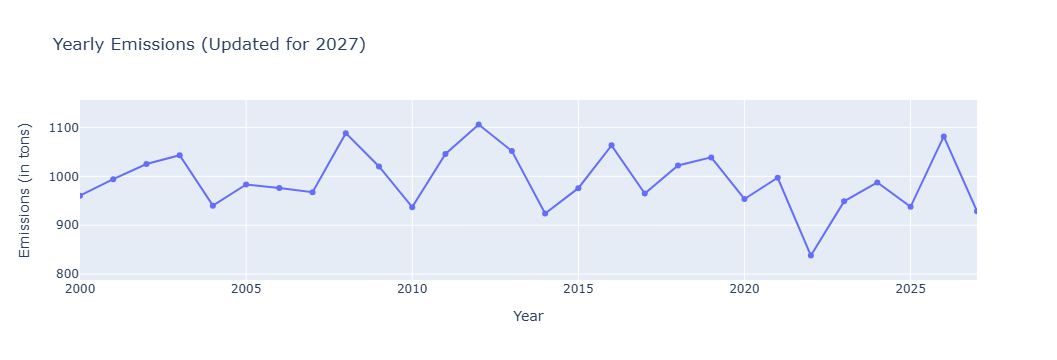

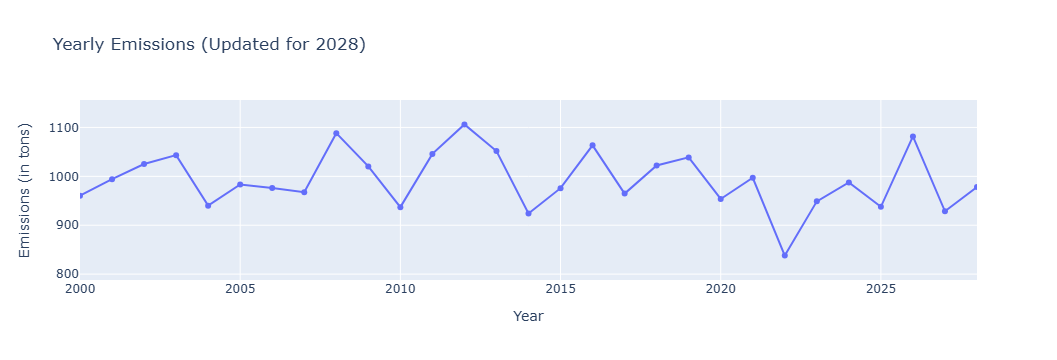

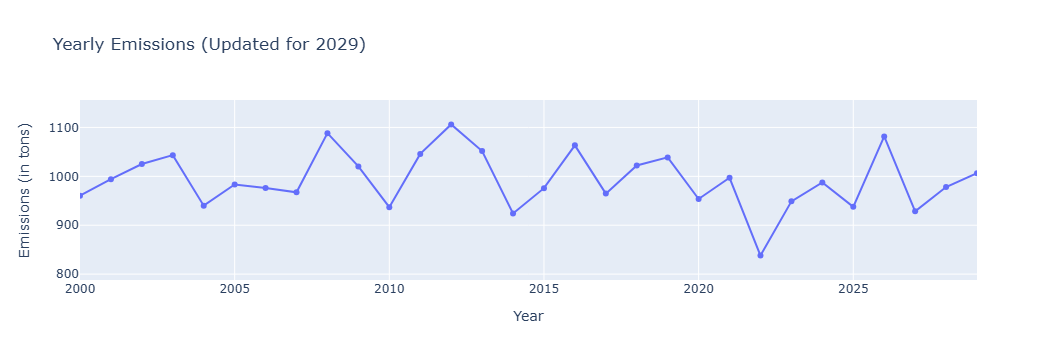

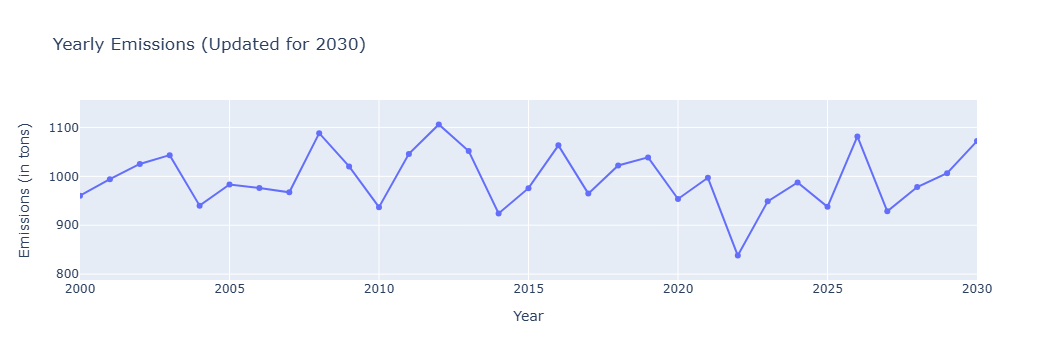

In [48]:
import plotly.graph_objects as go
import numpy as np
import time

# Initial data setup
years = np.arange(2000, 2021)
emissions = np.random.normal(loc=1000, scale=50, size=years.size)

fig = go.Figure()

# Create a line graph
fig.add_trace(go.Scatter(x=years, y=emissions, mode='lines+markers'))

# Layout configuration
fig.update_layout(
    title='Yearly Emissions',
    xaxis_title='Year',
    yaxis_title='Emissions (in tons)',
    xaxis=dict(range=[min(years), max(years)]),
    yaxis=dict(range=[min(emissions), max(emissions)])
)

fig.show()

# Simulating live updates
for _ in range(10):  # Update the plot 10 times
    # Generate new data point
    new_year = max(years) + 1
    new_emission = np.random.normal(loc=1000, scale=50)
    
    # Append new data
    years = np.append(years, new_year)
    emissions = np.append(emissions, new_emission)
    
    # Update the figure
    fig.data[0].x = years
    fig.data[0].y = emissions
    fig.layout.xaxis.range = [min(years), max(years)]
    fig.layout.yaxis.range = [min(emissions) - 50, max(emissions) + 50]
    fig.layout.title.text = f'Yearly Emissions (Updated for {new_year})'
    
    fig.show()
    
    # Wait for a second before the next update
    time.sleep(1)

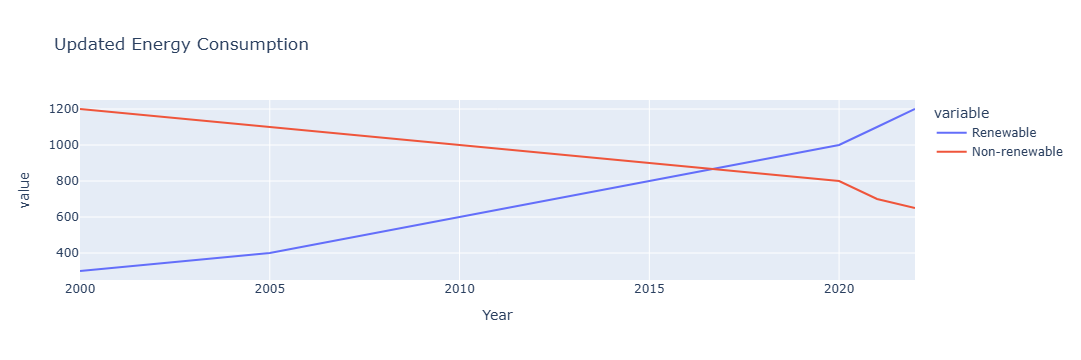

In [49]:
# Simulated database pull
def fetch_data():
    # Simulating a database update
    new_data = {
        'Year': [2021, 2022],
        'Renewable': [1100, 1200],
        'Non-renewable': [700, 650]
    }
    return pd.DataFrame(new_data)

# Updating the plot dynamically
new_df = fetch_data()
df = pd.concat([df, new_df])
fig = px.line(df, x='Year', y=['Renewable', 'Non-renewable'], title='Updated Energy Consumption')
fig.show()

In [57]:
# My version
import pandas as pd
import plotly.express as px

import pandas as pd

data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'Brazil_Renewable': [350, 375, 400, 425, 450],
    'Brazil_Non-renewable': [555, 655, 675, 705, 725],
    'Germany_Renewable': [450, 575, 600, 525, 550],
    'Germany_Non-renewable': [555, 675, 775, 805, 925],
    'Canada_Renewable': [550, 575, 500, 725, 850],
    'Canada_Non-renewable': [655, 755, 875, 905, 1025],
    'Russia_Renewable': [750, 875, 900, 925, 950],
    'Russia_Non-renewable': [1355, 1555, 1675, 1505, 1325]
}

df = pd.DataFrame(data)
print(df.head())

   Year  Brazil_Renewable  Brazil_Non-renewable  Germany_Renewable  \
0  2000               350                   555                450   
1  2005               375                   655                575   
2  2010               400                   675                600   
3  2015               425                   705                525   
4  2020               450                   725                550   

   Germany_Non-renewable  Canada_Renewable  Canada_Non-renewable  \
0                    555               550                   655   
1                    675               575                   755   
2                    775               500                   875   
3                    805               725                   905   
4                    925               850                  1025   

   Russia_Renewable  Russia_Non-renewable  
0               750                  1355  
1               875                  1555  
2               900                  1

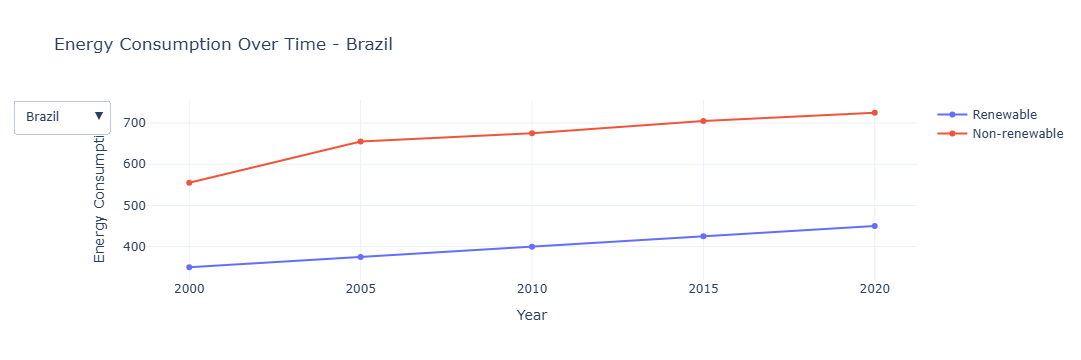

In [58]:
fig = go.Figure()

#Brazil
fig.add_trace(go.Scatter(
    x=df['Year'],
    y=df['Brazil_Renewable'],
    mode='lines+markers',
    name='Renewable'
))

fig.add_trace(go.Scatter(
    x=df['Year'],
    y=df['Brazil_Non-renewable'],
    mode='lines+markers',
    name='Non-renewable'
))

fig.update_layout(
    title='Energy Consumption Over Time - Brazil',
    xaxis_title='Year',
    yaxis_title='Energy Consumption',
    template='plotly_white',
    updatemenus=[
        dict(
            type='dropdown',
            direction='down',
            buttons=[
                dict(
                    label='Brazil',
                    method='update',
                    args=[
                        {'y': [df['Brazil_Renewable'], df['Brazil_Non-renewable']]},
                        {'title': 'Energy Consumption Over Time - Brazil'}
                    ]
                ),
                dict(
                    label='Germany',
                    method='update',
                    args=[
                        {'y': [df['Germany_Renewable'], df['Germany_Non-renewable']]},
                        {'title': 'Energy Consumption Over Time - Germany'}
                    ]
                ),
                dict(
                    label='Canada',
                    method='update',
                    args=[
                        {'y': [df['Canada_Renewable'], df['Canada_Non-renewable']]},
                        {'title': 'Energy Consumption Over Time - Canada'}
                    ]
                ),
                dict(
                    label='Russia',
                    method='update',
                    args=[
                        {'y': [df['Russia_Renewable'], df['Russia_Non-renewable']]},
                        {'title': 'Energy Consumption Over Time - Russia'}
                    ]
                )
            ]
        )
    ]
)

fig.show()

# Interactive line chart
This chart shows all countries and both energy types over time.

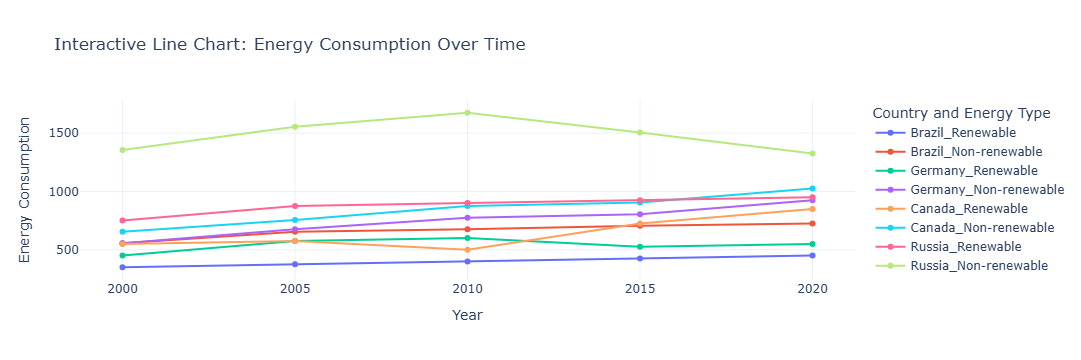

In [59]:
fig_line = px.line(
    df,
    x='Year',
    y=[
        'Brazil_Renewable', 'Brazil_Non-renewable',
        'Germany_Renewable', 'Germany_Non-renewable',
        'Canada_Renewable', 'Canada_Non-renewable',
        'Russia_Renewable', 'Russia_Non-renewable'
    ],
    markers=True,
    title='Interactive Line Chart: Energy Consumption Over Time',
    labels={
        'value': 'Energy Consumption',
        'variable': 'Country and Energy Type'
    }
)

fig_line.update_layout(
    template='plotly_white',
    hovermode='x unified',
    xaxis_title='Year',
    yaxis_title='Energy Consumption'
)

fig_line.show()

# Interactive bar chart
Bar chart comparing all countries on year 2020

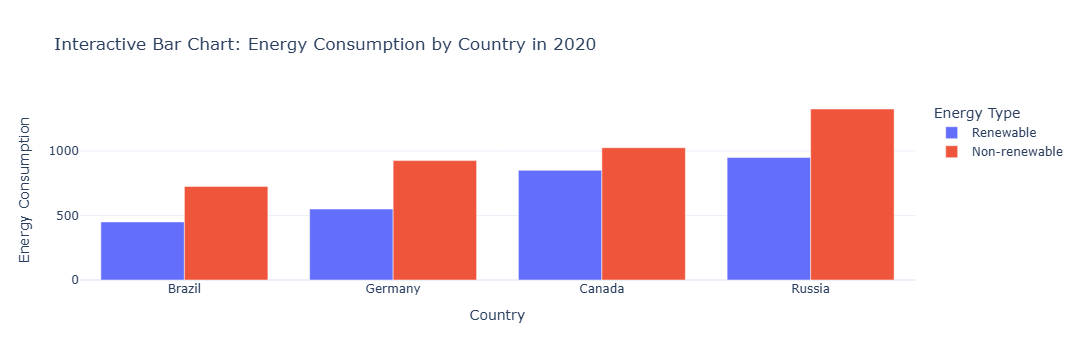

In [60]:
bar_data = pd.DataFrame({
    'Country': ['Brazil', 'Brazil', 'Germany', 'Germany', 'Canada', 'Canada', 'Russia', 'Russia'],
    'Energy Type': ['Renewable', 'Non-renewable'] * 4,
    'Consumption': [
        df.loc[df['Year'] == 2020, 'Brazil_Renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Brazil_Non-renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Germany_Renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Germany_Non-renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Canada_Renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Canada_Non-renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Russia_Renewable'].values[0],
        df.loc[df['Year'] == 2020, 'Russia_Non-renewable'].values[0]
    ]
})

fig_bar = px.bar(
    bar_data,
    x='Country',
    y='Consumption',
    color='Energy Type',
    barmode='group',
    title='Interactive Bar Chart: Energy Consumption by Country in 2020',
    labels={'Consumption': 'Energy Consumption'}
)

fig_bar.update_layout(
    template='plotly_white',
    xaxis_title='Country',
    yaxis_title='Energy Consumption'
)

fig_bar.show()

# Dropdown filter for energy type
The dropdown menu lets the use choose both renewable and/or non-renewable on all countries

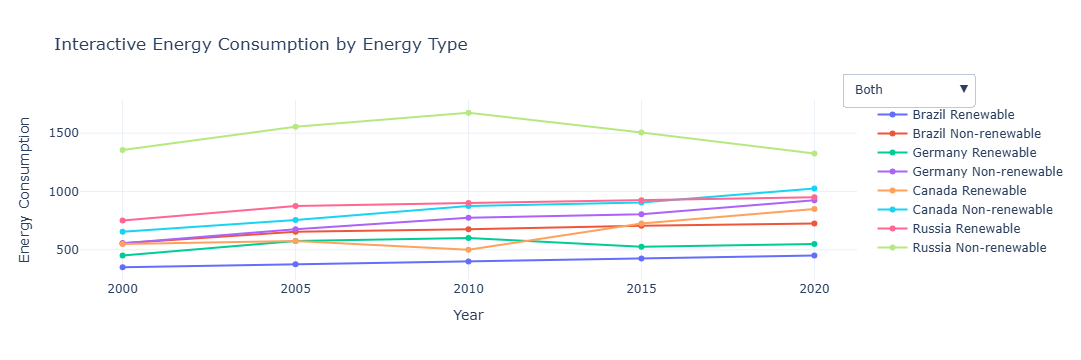

In [61]:
fig_dropdown = go.Figure()

# Add all 8 traces
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Brazil_Renewable'],
    mode='lines+markers', name='Brazil Renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Brazil_Non-renewable'],
    mode='lines+markers', name='Brazil Non-renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Germany_Renewable'],
    mode='lines+markers', name='Germany Renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Germany_Non-renewable'],
    mode='lines+markers', name='Germany Non-renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Canada_Renewable'],
    mode='lines+markers', name='Canada Renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Canada_Non-renewable'],
    mode='lines+markers', name='Canada Non-renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Russia_Renewable'],
    mode='lines+markers', name='Russia Renewable'
))
fig_dropdown.add_trace(go.Scatter(
    x=df['Year'], y=df['Russia_Non-renewable'],
    mode='lines+markers', name='Russia Non-renewable'
))

fig_dropdown.update_layout(
    title='Interactive Energy Consumption by Energy Type',
    xaxis_title='Year',
    yaxis_title='Energy Consumption',
    template='plotly_white',
    hovermode='x unified',
    updatemenus=[
        dict(
            type='dropdown',
            direction='down',
            buttons=[
                dict(
                    label='Both',
                    method='update',
                    args=[
                        {'visible': [True, True, True, True, True, True, True, True]},
                        {'title': 'Energy Consumption: Renewable and Non-renewable'}
                    ]
                ),
                dict(
                    label='Renewable',
                    method='update',
                    args=[
                        {'visible': [True, False, True, False, True, False, True, False]},
                        {'title': 'Energy Consumption: Renewable Only'}
                    ]
                ),
                dict(
                    label='Non-renewable',
                    method='update',
                    args=[
                        {'visible': [False, True, False, True, False, True, False, True]},
                        {'title': 'Energy Consumption: Non-renewable Only'}
                    ]
                )
            ],
            x=1.15,
            y=1.15
        )
    ]
)

fig_dropdown.show()

# Evaluation of the visualizations
These interactive visualizations were designed to make energy consumption data easier to explore and compare across Brazil, Germany, Canada, and Russia. The line chart is suitable for showing changes over time, allowing users to observe trends in both renewable and non-renewable energy consumption. The bar chart is effective for comparing countries in a single year, making differences between energy types more immediately visible. The dropdown chart improves user interaction by allowing users to filter the visualization by energy type, which reduces clutter and supports more focused analysis. The interactive features adds value to the exploration process. Zoom functionality allows users to focus on specific time ranges, and the legend can be used to hide or show selected traces. The dropdown menu is intuitive because it offers clear filtering options: both energy types, renewable only, or non-renewable only. The design choices consist of: consistent titles, axis labels, and a clean white template

# Creating Dashboards with Dash

In [62]:
pip install dash dash-bootstrap-components

Note: you may need to restart the kernel to use updated packages.


In [1]:
import dash
from dash import html, dcc
import plotly.express as px
import pandas as pd

# Sample data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'Emissions': [5.0, 5.5, 6.0, 6.5, 7.0]
}
df = pd.DataFrame(data)

# Creating a Plotly graph
fig = px.line(df, x='Year', y='Emissions', title='Carbon Emissions Over Time')

# Initialize the Dash app
app = dash.Dash(__name__)

# Define the layout of the app
app.layout = html.Div([
    html.H1("Climate Change Dashboard"),
    dcc.Graph(figure=fig)
])

# Run the app
if __name__ == '__main__':
    app.run(debug=True)

In [65]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd

# Example data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'Emissions': [5.0, 5.5, 6.0, 6.5, 7.0],
    'Region': ['USA', 'USA', 'Europe', 'Asia', 'Europe']
}
df = pd.DataFrame(data)

app = Dash(__name__)

app.layout = html.Div([
    dcc.Dropdown(
        id='region-dropdown',
        options=[{'label': i, 'value': i} for i in df['Region'].unique()],
        value='USA'
    ),
    dcc.Graph(id='emissions-graph'),
    dcc.Slider(
        id='year-slider',
        min=df['Year'].min(),
        max=df['Year'].max(),
        value=df['Year'].max(),
        marks={str(year): str(year) for year in df['Year'].unique()},
        step=None
    )
])

@app.callback(
    Output('emissions-graph', 'figure'),
    [Input('region-dropdown', 'value'),
     Input('year-slider', 'value')]
)
def update_graph(selected_region, selected_year):
    filtered_df = df[(df['Year'] <= selected_year) & (df['Region'] == selected_region)]
    fig = px.line(filtered_df, x='Year', y='Emissions', title=f'Carbon Emissions in {selected_region}')
    return fig

if __name__ == '__main__':
    app.run(debug=True)

In [ ]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd
data = {
    'Year': [
        2000, 2005, 2010, 2015, 2020,
        2000, 2005, 2010, 2015, 2020,
        2000, 2005, 2010, 2015, 2020,
        2000, 2005, 2010, 2015, 2020
    ],
    'Region': [
        'North America', 'North America', 'North America', 'North America', 'North America',
        'Europe', 'Europe', 'Europe', 'Europe', 'Europe',
        'Asia', 'Asia', 'Asia', 'Asia', 'Asia',
        'Africa', 'Africa', 'Africa', 'Africa', 'Africa'
    ],
    'Emissions': [
        6.5, 6.8, 7.0, 7.3, 7.6,
        5.2, 5.0, 4.8, 4.6, 4.4,
        4.0, 4.8, 5.7, 6.6, 7.5,
        1.0, 1.2, 1.4, 1.6, 1.9
    ]
}

df = pd.DataFrame(data)
app = Dash(__name__)
app.layout = html.Div([
    html.H1("Carbon Emissions Dashboard", style={'textAlign': 'center'}),

    html.P(
        "Explore carbon emissions trends by region and year.",
        style={'textAlign': 'center'}
    ),

    html.Label("Select Region:"),
    dcc.Dropdown(
        id='region-dropdown',
        options=[{'label': region, 'value': region} for region in df['Region'].unique()],
        value='Europe',
        clearable=False
    ),

    html.Br(),

    html.Label("Select Maximum Year:"),
    dcc.Slider(
        id='year-slider',
        min=df['Year'].min(),
        max=df['Year'].max(),
        value=df['Year'].max(),
        marks={int(year): str(int(year)) for year in sorted(df['Year'].unique())},
        step=None
    ),

    html.Br(),

    html.Button("Reset Filters", id='reset-button', n_clicks=0),

    html.Br(),
    html.Br(),

    dcc.Graph(id='emissions-line-chart'),

    html.Br(),

    dcc.Graph(id='emissions-bar-chart')
], style={'width': '80%', 'margin': 'auto', 'fontFamily': 'Arial'})
@app.callback(
    [Output('region-dropdown', 'value'),
     Output('year-slider', 'value'),
     Output('emissions-line-chart', 'figure'),
     Output('emissions-bar-chart', 'figure')],
    [Input('region-dropdown', 'value'),
     Input('year-slider', 'value'),
     Input('reset-button', 'n_clicks')]
)
def update_dashboard(selected_region, selected_year, n_clicks):
    # Reset filters when button is clicked
    if n_clicks > 0:
        selected_region = 'Europe'
        selected_year = df['Year'].max()

    # Filter data
    filtered_df = df[df['Year'] <= selected_year]

    # Line chart
    line_fig = px.line(
        filtered_df,
        x='Year',
        y='Emissions',
        markers=True,
        title=f'Carbon Emissions Trend in {selected_region}'
    )

    line_fig.update_layout(
        xaxis_title='Year',
        yaxis_title='Emissions (Metric Tons per Capita)'
    )
    bar_fig = px.bar(
        filtered_df,
        x='Year',
        y='Emissions',
        title=f'Carbon Emissions by Year in {selected_region}'
    )

    bar_fig.update_layout(
        xaxis_title='Year',
        yaxis_title='Emissions (Metric Tons per Capita)'
    )

    return selected_region, selected_year, line_fig, bar_fig
if __name__ == '__main__':
    app.run(debug=True)

# Reflection on design and functionality
This dashboard was created to show carbon emissions trends interactively. It includes a dropdown menu to select a region, a slider to choose the maximum year displayed, and a reset button to return to the default settings. The line chart is useful for showing how emissions change over time, while the bar chart helps compare yearly values more clearly. Using both charts makes the dashboard more informative and easier to understand. The dashboard updates dynamically in response to user input. When the user selects a different region, changes the year slider, or presses the reset button, the graphs update immediately without reloading the page.

# Advanced Web Apps with Flask

In [69]:
import pandas as pd
import random

# Generate sample data
years = list(range(2000, 2021))
emissions = [random.uniform(5.0, 7.0) for _ in range(len(years))]
regions = ['USA', 'Europe', 'Asia']

# Repeat regions to match the length of years and emissions
regions = [region for region in regions for _ in range(len(years) // len(regions))]

# Create DataFrame
df = pd.DataFrame({
    'Year': years,
    'Emissions': emissions,
    'Region': regions
})

# Save DataFrame to CSV
df.to_csv('climate_data.csv', index=False)

# Flask Web Application Setup
Project Structure: To build the Flask web application, I created a structured project directory:
* flask_project/
├── app.py
├── climate_data.csv
└── templates/
    └── home.html
** app.py: Contains the Flask backend logic
** templates/: Required folder where Flask looks for HTML files
** home.html: Frontend template rendered by Flask
The Flask application was implemented in app.py.
app = Flask(__name__) * Flask initialization
@app.route('/')
def home(): * defines the homepage of the web app.
df = pd.read_csv('climate_data.csv') * The dataset is loaded using Pandas.
return render_template('home.html', data=df.to_html()) * Flask passes the dataset to the HTML template.

# The file home.html was placed inside the templates folder (required by Flask).
{{ data | safe }} * This allows dynamic rendering of the DataFrame as an HTML table.
# Running the Application
The Flask app was executed from the terminal:
python C:\Users\caste\flask_project\app.py
Because an older Flask process was still using port 5000, I changed the app to run on port 5001. After that, the correct application loaded successfully in the browser.
The browser displayed the climate change data table. 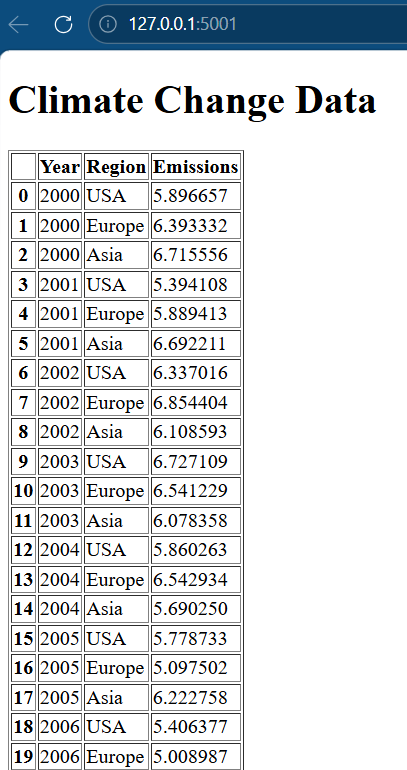 Check previous error messages: 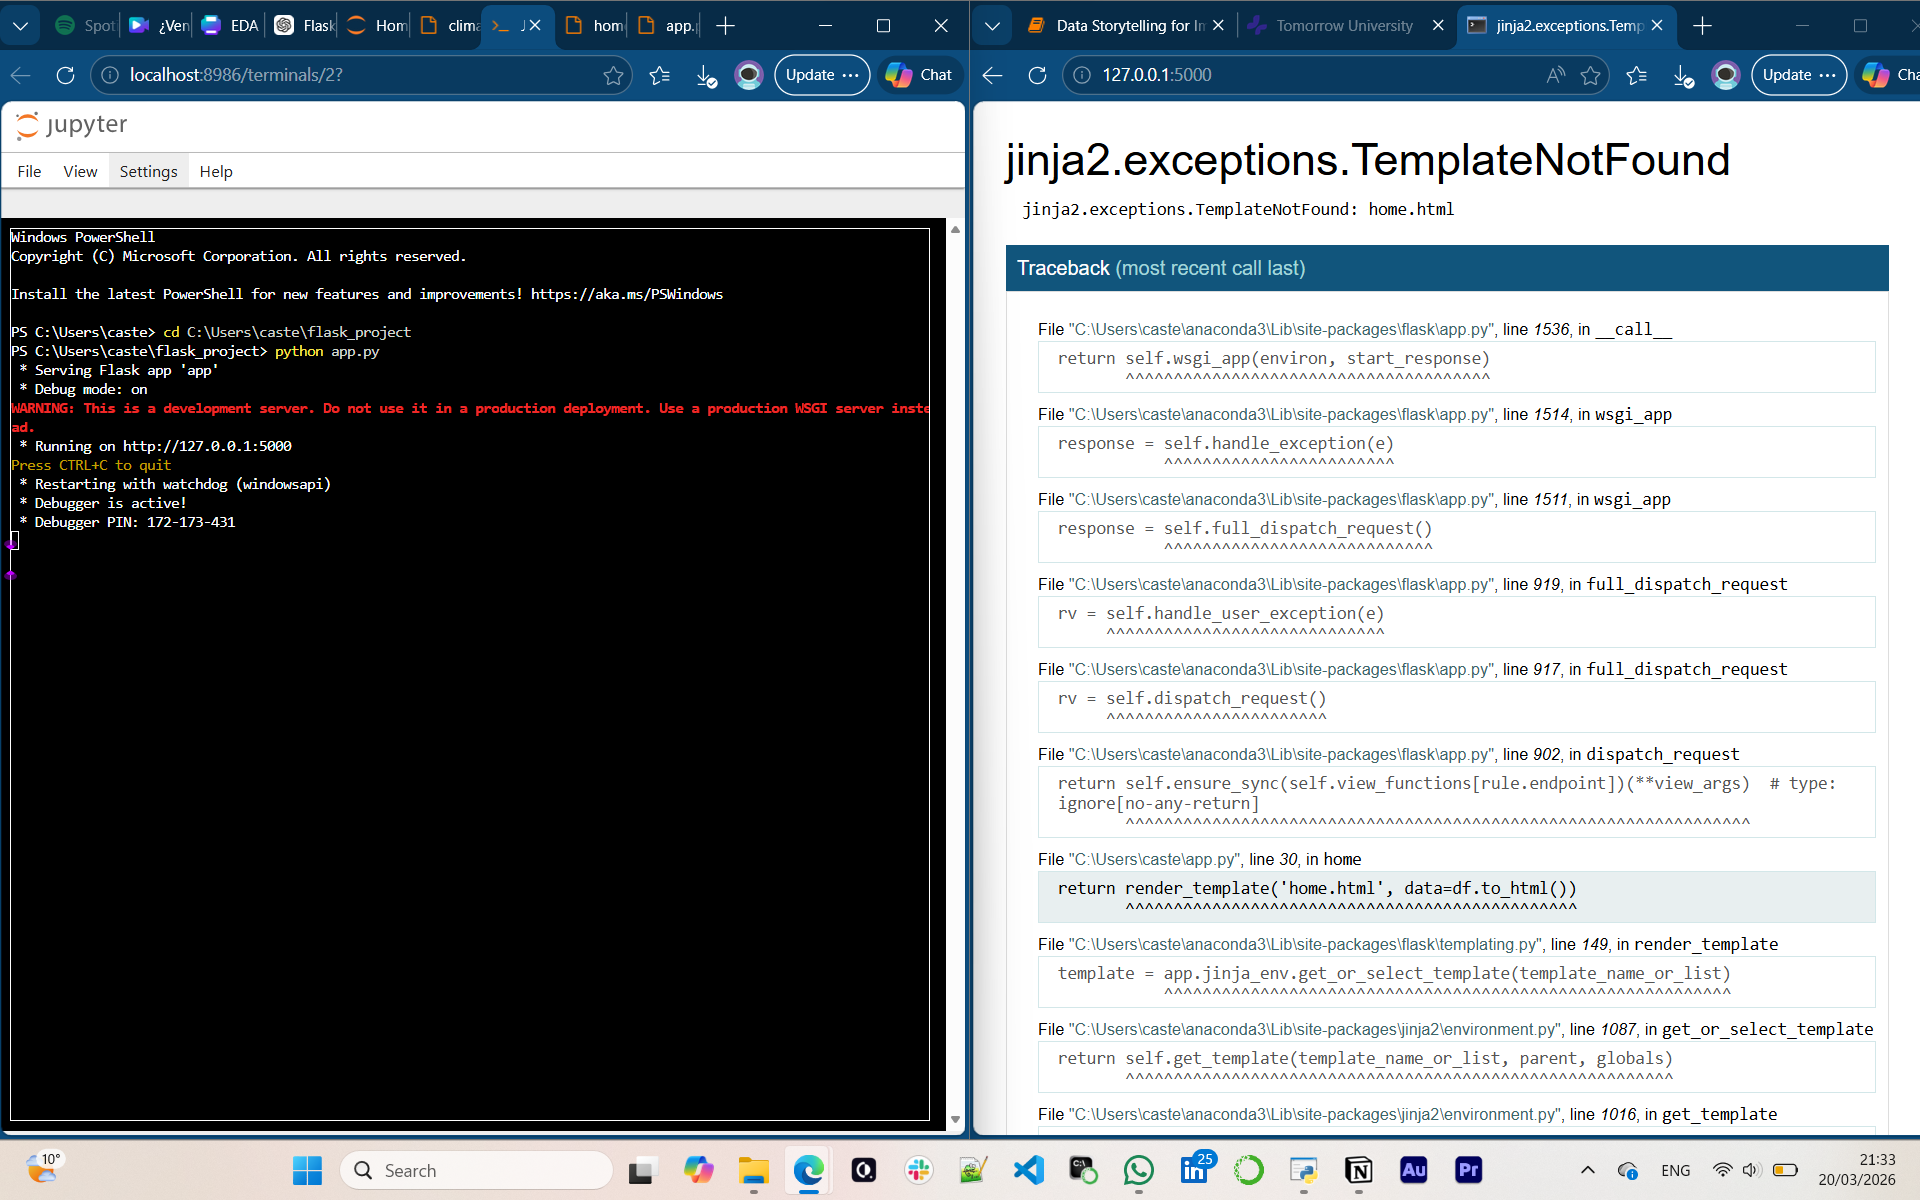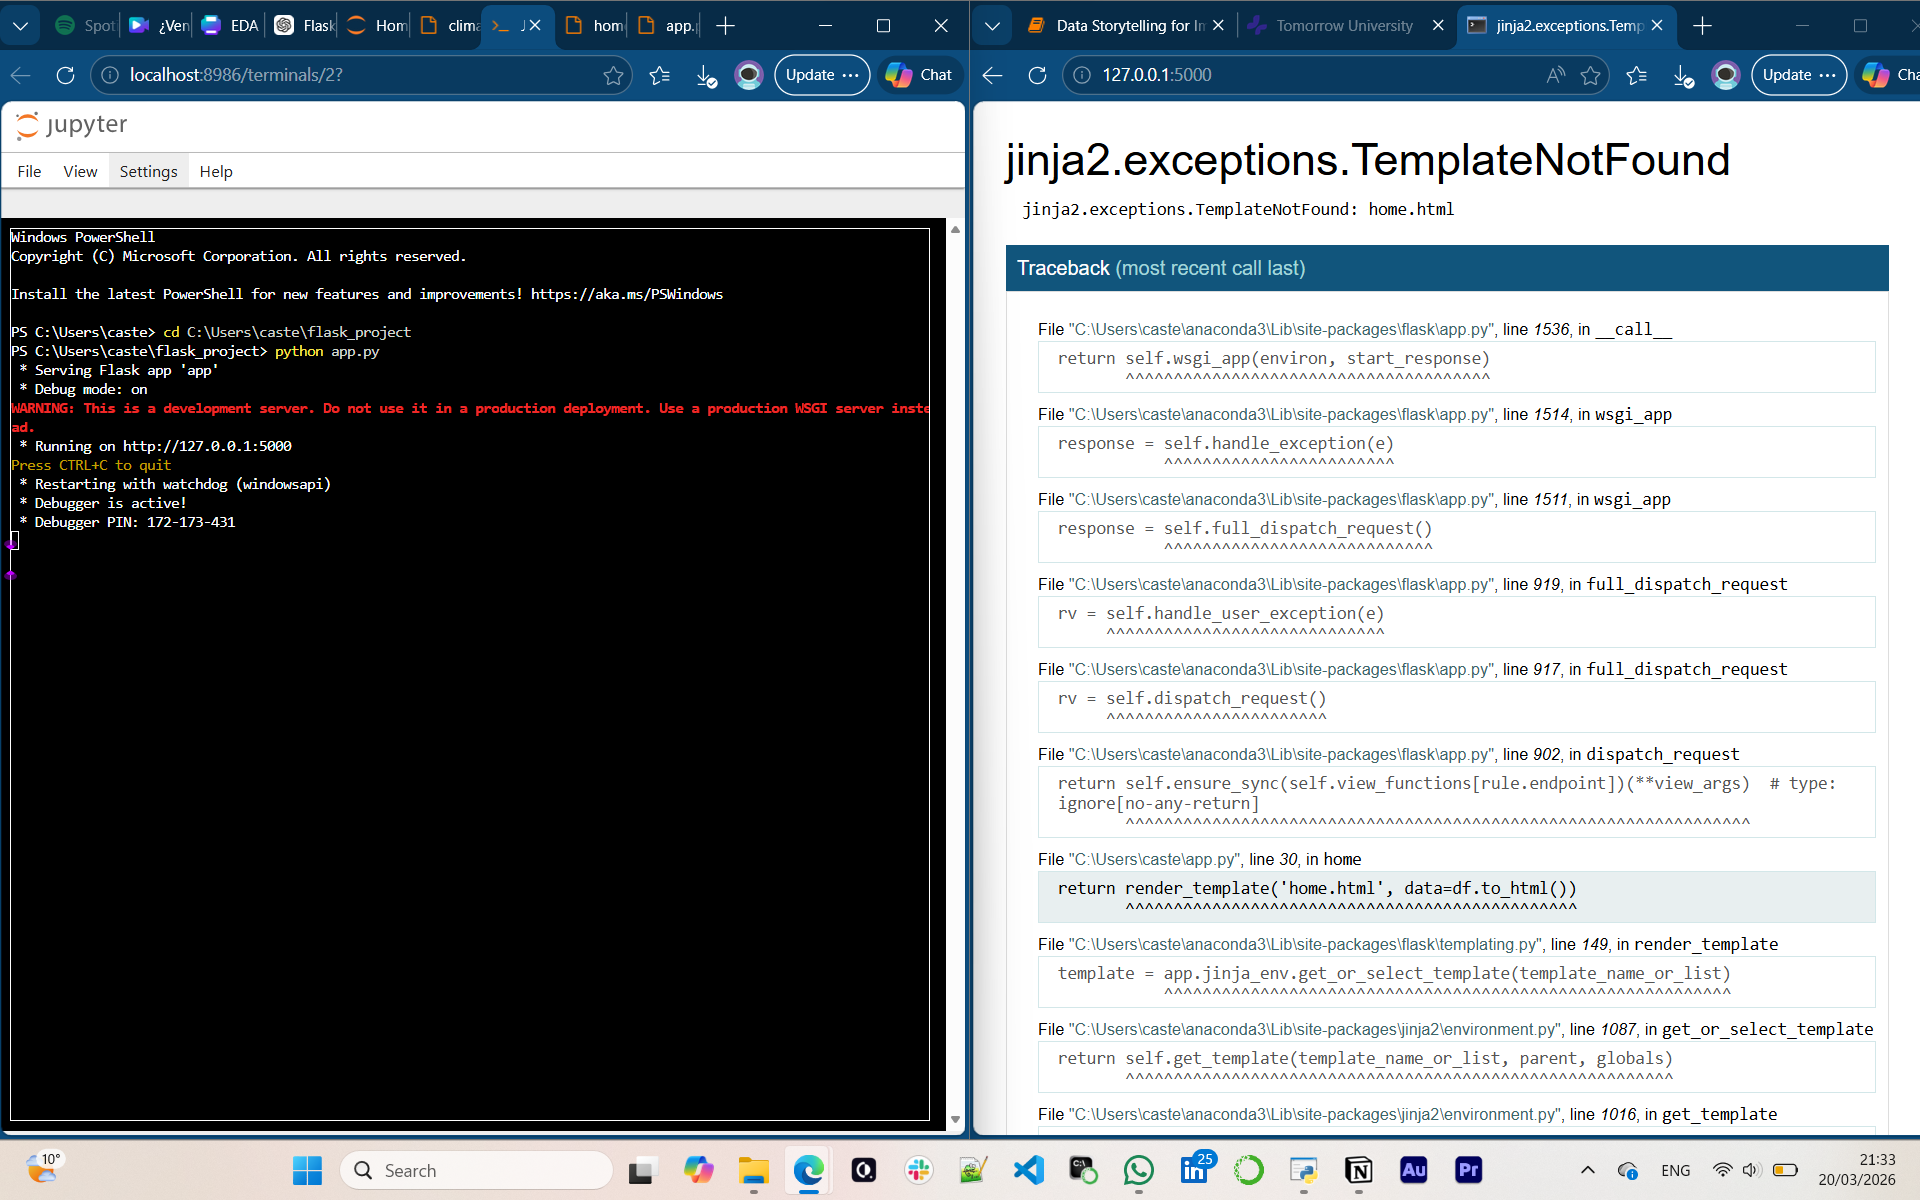 During this task, I learned that Flask applications must be run from a Python script rather than directly inside Jupyter Notebook. I also learned that Flask looks for HTML files inside a dedicated templates folder. After debugging the TemplateNotFound error and resolving a port conflict, I successfully rendered a dataset from Pandas into a web page.

In [78]:
import os

data_path = "climate_app/templates/Climate_Change_Data.csv"

print("Dataset exists:", os.path.exists(data_path))

Dataset exists: True


In [79]:
import pandas as pd

df = pd.read_csv("climate_app/templates/Climate_Change_Data.csv")
df.head()

,Year,Global Average Temperature (°C),CO2 Emissions (Million Tonnes),Sea Level Rise (mm)
0,2000,14.50,30000,50
1,2001,14.51,30100,52
2,2002,14.52,30200,54
3,2003,14.53,30300,56
4,2004,14.54,30400,58


# Reflection Paragraph (Capstone Project)
During the development of the climate change dashboard, several technical challenges were encountered and resolved. The project required integrating Python, Flask, HTML templates, and Plotly visualizations while managing the project structure and file paths correctly. One of the main issues was related to file paths, as the dataset could not initially be located by the Flask application. This problem occurred because the application was executed from a different working directory than the location of the dataset. To solve this, the dataset path was constructed dynamically using Python’s os module and the directory of the app.py file, ensuring that the dataset could be loaded reliably regardless of where the application was executed from.

Another issue involved running multiple Flask applications simultaneously. Since a previous project was already using port 5000 and another was using port 5001, the new application was configured to run on port 5002. This demonstrated the importance of understanding how web servers use ports and how to resolve conflicts when multiple applications are running locally.

Additionally, the project required careful organization of folders, including placing HTML files inside a templates folder and ensuring the dataset and application files were stored in the correct directory structure. Debugging tools such as checking the working directory, verifying file existence, and printing directory contents were used to diagnose and resolve issues.

Overall, this project helped develop a better understanding of project structure, file management, Flask routing, HTML templating, and integrating data visualization into a web application. The process involved significant troubleshooting and problem-solving, which improved my understanding of how Python web applications interact with file systems and local servers.
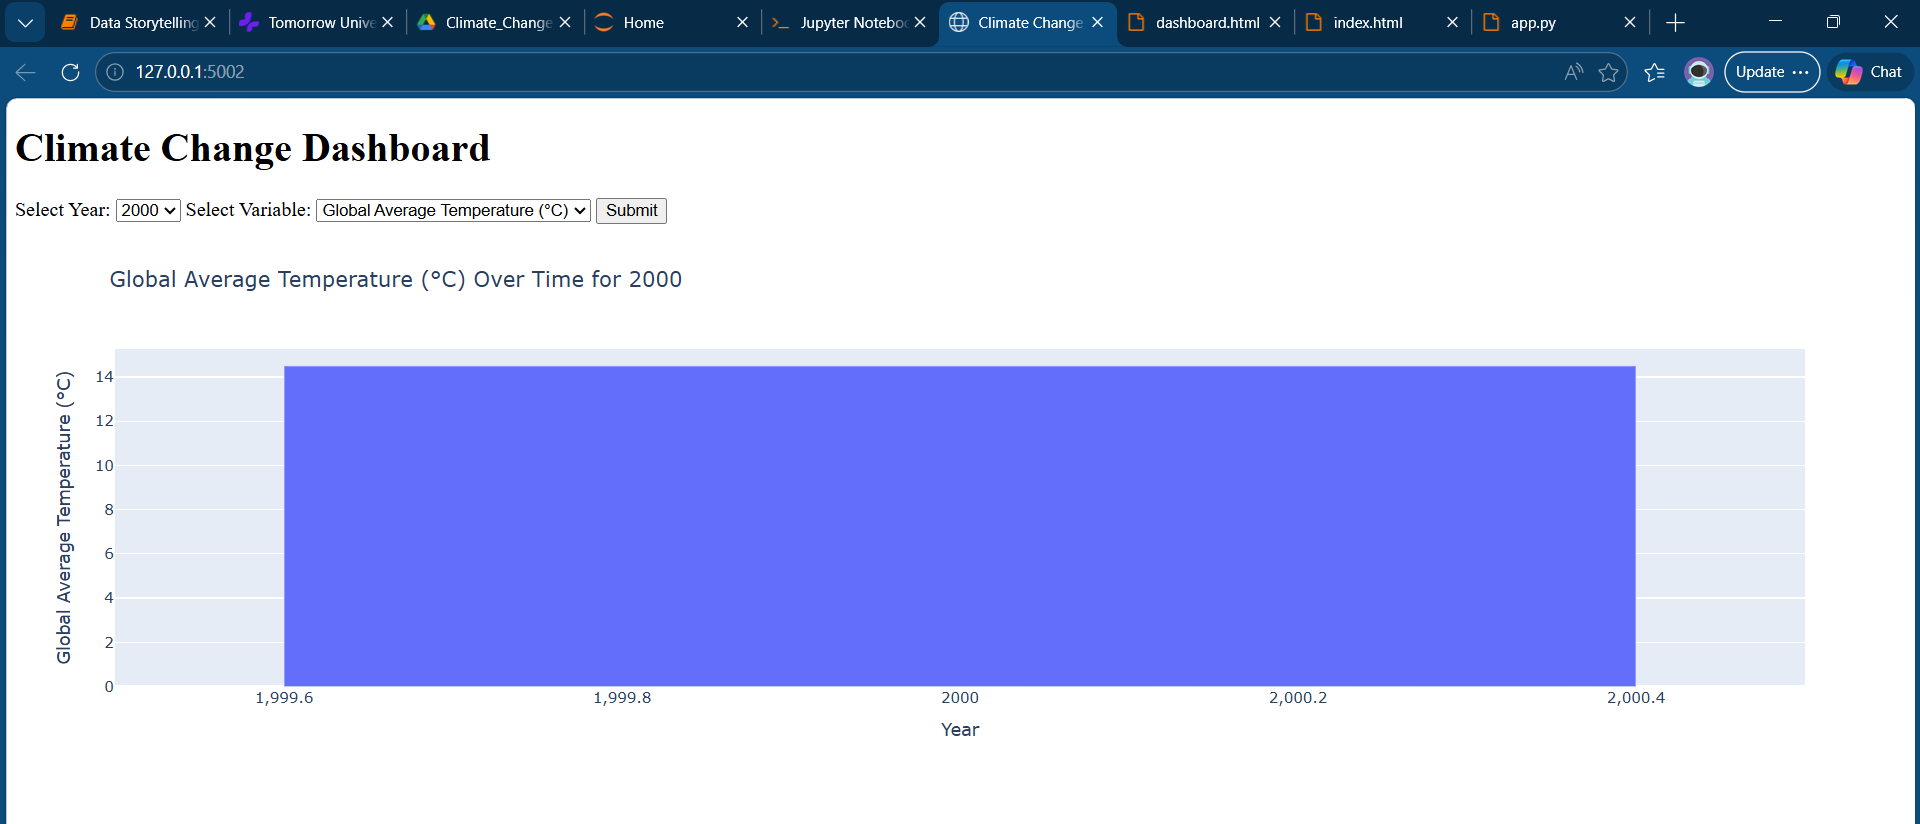